In [3]:
!pip install pandas scikit-learn nltk matplotlib

In [4]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\talha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\talha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
# %%
import os
import re
from typing import List, Dict
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt

# Ensure NLTK assets (download if not present)
try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
    nltk.download("punkt")

STOPWORDS = set(stopwords.words("english"))

In [6]:
# %%
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-\+_\.]", " ", text)
    text = re.sub(r"\s{2,}", " ", text).strip()
    return text

def simple_tokenize(text: str) -> List[str]:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS and len(t) > 1]
    return tokens

In [7]:
# %%
class SkillGapAnalyzer:
    def __init__(self, n_clusters: int = 5, top_k_terms: int = 20, random_state: int = 42):
        self.n_clusters = n_clusters
        self.top_k_terms = top_k_terms
        self.random_state = random_state
        self.vectorizer = None
        self.km = None
        self.feature_names = None
        self.cluster_centers = None
        self.job_tfidf_matrix = None
        self.job_labels = None

    def fit_jobs(self, job_texts: List[str]):
        cleaned = [clean_text(t) for t in job_texts]
        # Use unigrams + bigrams (helps multi-word skills)
        self.vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.85, min_df=1, max_features=6000)
        X = self.vectorizer.fit_transform(cleaned)
        self.feature_names = self.vectorizer.get_feature_names_out()

        self.km = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.km.fit(X)
        self.job_tfidf_matrix = X
        self.job_labels = self.km.labels_
        self.cluster_centers = self.km.cluster_centers_
        return X

    def top_terms_per_cluster(self) -> Dict[int, List[str]]:
        if self.km is None or self.feature_names is None:
            raise RuntimeError("Model not trained yet.")
        centers = self.cluster_centers
        top_terms = {}
        for i, center in enumerate(centers):
            top_idx = np.argsort(center)[::-1][:self.top_k_terms]
            terms = [self.feature_names[idx] for idx in top_idx]
            top_terms[i] = terms
        return top_terms

    def map_interns_to_cluster(self, intern_texts: List[str]) -> List[int]:
        if self.vectorizer is None or self.km is None:
            raise RuntimeError("Model not trained yet.")
        cleaned = [clean_text(t) for t in intern_texts]
        X_intern = self.vectorizer.transform(cleaned)
        sims = cosine_similarity(X_intern, self.cluster_centers)
        assigned = np.argmax(sims, axis=1).tolist()
        return assigned

    def compute_skill_gaps(self, intern_skills_list: List[str], assigned_clusters: List[int],
                           top_terms_by_cluster: Dict[int, List[str]], top_n_required: int = 20) -> List[Dict]:
        results = []
        for idx, skills_text in enumerate(intern_skills_list):
            # Parse provided skills (comma/pipe/semicolon separated)
            provided = [s.strip().lower() for s in re.split(r"[,\|;/]+", str(skills_text)) if s.strip()]
            provided_norm = set()
            for p in provided:
                p_clean = " ".join(simple_tokenize(p))
                if p_clean:
                    provided_norm.add(p_clean)

            cluster = assigned_clusters[idx]
            cluster_top = top_terms_by_cluster.get(cluster, [])[:top_n_required]

            # Normalize cluster terms to token-joined phrases
            cluster_norm = []
            for t in cluster_top:
                toks = simple_tokenize(t)
                if toks:
                    cluster_norm.append(" ".join(toks))

            missing = []
            for ct in cluster_norm:
                ct_words = set(ct.split())
                matched = False
                for pv in provided_norm:
                    pv_words = set(pv.split())
                    if len(ct_words & pv_words) > 0:
                        matched = True
                        break
                if not matched:
                    missing.append(ct)

            suggestions = [self._suggest_training_for_skill(m) for m in missing[:10]]

            results.append({
                "assigned_cluster": cluster,
                "provided_skills_parsed": list(provided_norm),
                "cluster_top_skills": cluster_top[:top_n_required],
                "missing_skills": missing,
                "suggestions": suggestions
            })
        return results

    def _suggest_training_for_skill(self, skill: str) -> str:
        skill_lower = skill.lower()
        mapping = {
            "machine learning": "Take an ML fundamentals course (e.g., Coursera / fast.ai).",
            "deep learning": "Study deep learning (fast.ai, Coursera 'Deep Learning').",
            "python": "Practice Python, pandas, numpy; take 'Python for Data Science'.",
            "sql": "Learn SQL basics and joins via interactive platforms (Mode, SQLZoo).",
            "docker": "Learn Docker: containers, images, hands-on labs.",
            "aws": "Start with AWS Cloud Practitioner and hands-on labs for S3/EC2/Lambda.",
            "nlp": "Take NLP courses and do hands-on spaCy/transformers tutorials.",
            "react": "Learn React by building small apps and following official docs.",
            "java": "Practice Java fundamentals and OOP, build small projects."
        }
        for key in mapping:
            if key in skill_lower:
                return f"{skill}: {mapping[key]}"
        return f"{skill}: Suggested learning — search short courses or tutorials for '{skill}'."

In [8]:
# %%
def load_csv_or_example(jobs_path="jobs.csv", interns_path="interns.csv"):
    if os.path.exists(jobs_path):
        jobs = pd.read_csv(jobs_path)
    else:
        jobs = pd.DataFrame([
            {"id": 1, "title": "Data Scientist", "description": "Machine learning, python, pandas, scikit-learn, deep learning, sql, data visualization."},
            {"id": 2, "title": "Backend Engineer", "description": "Java, spring boot, microservices, docker, kubernetes, rest apis, sql."},
            {"id": 3, "title": "Frontend Developer", "description": "Javascript, React, HTML, CSS, typescript, responsive design."},
            {"id": 4, "title": "ML Engineer", "description": "python, tensorflow, pytorch, ml pipelines, docker, aws, model deployment."},
            {"id": 5, "title": "DevOps Engineer", "description": "CI/CD, docker, kubernetes, aws, terraform, monitoring, linux."},
        ])
        print("jobs.csv not found — using example jobs dataset.")

    if os.path.exists(interns_path):
        interns = pd.read_csv(interns_path)
    else:
        interns = pd.DataFrame([
            {"id": 1, "name": "Aisha", "skills": "python, pandas, sql, data visualization"},
            {"id": 2, "name": "Bilal", "skills": "html, css, javascript"},
            {"id": 3, "name": "Sana", "skills": "java, spring"},
            {"id": 4, "name": "Omar", "skills": "linux, docker"},
        ])
        print("interns.csv not found — using example interns dataset.")

    # Fill missing columns if any
    for col in ["id", "title", "description"]:
        if col not in jobs.columns:
            jobs[col] = ""
    for col in ["id", "name", "skills"]:
        if col not in interns.columns:
            interns[col] = ""

    return jobs, interns

In [9]:
# %%
# Parameters
N_CLUSTERS = 3   # change depending on data
TOP_TERMS = 25

# Load data
jobs_df, interns_df = load_csv_or_example()
job_texts = (jobs_df['title'].fillna("") + " . " + jobs_df['description'].fillna("")).tolist()
intern_texts = interns_df['skills'].fillna("").tolist()

# Fit analyzer
analyzer = SkillGapAnalyzer(n_clusters=N_CLUSTERS, top_k_terms=TOP_TERMS, random_state=42)
analyzer.fit_jobs(job_texts)
top_terms = analyzer.top_terms_per_cluster()
assigned = analyzer.map_interns_to_cluster(intern_texts)
results = analyzer.compute_skill_gaps(intern_texts, assigned, top_terms, top_n_required=20)

# Attach results to interns_df for display
interns_df = interns_df.reset_index(drop=True)
interns_df['assigned_cluster'] = [r['assigned_cluster'] for r in results]
interns_df['provided_skills_parsed'] = [r['provided_skills_parsed'] for r in results]
interns_df['cluster_top_skills'] = [r['cluster_top_skills'] for r in results]
interns_df['missing_skills'] = [r['missing_skills'] for r in results]
interns_df['suggestions'] = [r['suggestions'] for r in results]

# Display
pd.set_option('display.max_colwidth', 200)
interns_df

jobs.csv not found — using example jobs dataset.
interns.csv not found — using example interns dataset.


,id,name,skills,assigned_cluster,provided_skills_parsed,cluster_top_skills,missing_skills,suggestions
0,1,Aisha,"python, pandas, sql, data visualization",0,"[python, data visualization, pandas, sql]","[learning, data, visualization, scientist, scientist machine, scikit, python pandas, pandas scikit, learning sql, sql data, scikit learn, pandas, learning python, machine, deep, data scientist, de...","[learning, scientist, scientist machine, scikit, scikit learn, machine, deep, deep learning, learn, learn deep]","[learning: Suggested learning — search short courses or tutorials for 'learning'., scientist: Suggested learning — search short courses or tutorials for 'scientist'., scientist machine: Suggested ..."
1,2,Bilal,"html, css, javascript",2,"[html, css, javascript]","[typescript responsive, typescript, responsive design, react html, react, responsive, frontend developer, html, javascript, html css, frontend, developer, design, javascript react, css typescript,...","[typescript responsive, typescript, responsive design, react, responsive, frontend developer, frontend, developer, design, scientist, sql data, spring]","[typescript responsive: Suggested learning — search short courses or tutorials for 'typescript responsive'., typescript: Suggested learning — search short courses or tutorials for 'typescript'., r..."
2,3,Sana,"java, spring",1,"[java, spring]","[docker, engineer, ml, kubernetes, docker kubernetes, aws, linux, monitoring linux, terraform monitoring, terraform, engineer ci, cd, cd docker, monitoring, kubernetes aws, devops, devops engineer...","[docker, engineer, ml, kubernetes, docker kubernetes, aws, linux, monitoring linux, terraform monitoring, terraform, engineer ci, cd, cd docker, monitoring, kubernetes aws, devops, devops engineer...","[docker: Learn Docker: containers, images, hands-on labs., engineer: Suggested learning — search short courses or tutorials for 'engineer'., ml: Suggested learning — search short courses or tutori..."
3,4,Omar,"linux, docker",1,"[linux, docker]","[docker, engineer, ml, kubernetes, docker kubernetes, aws, linux, monitoring linux, terraform monitoring, terraform, engineer ci, cd, cd docker, monitoring, kubernetes aws, devops, devops engineer...","[engineer, ml, kubernetes, aws, terraform monitoring, terraform, engineer ci, cd, monitoring, kubernetes aws, devops, devops engineer, ci cd, aws terraform, ci]","[engineer: Suggested learning — search short courses or tutorials for 'engineer'., ml: Suggested learning — search short courses or tutorials for 'ml'., kubernetes: Suggested learning — search sho..."


In [10]:
# %%
# build aggregate counts of missing skills across interns
from collections import Counter
cnt = Counter()
for r in results:
    cnt.update(r['missing_skills'])

if len(cnt) > 0:
    missing_df = pd.DataFrame(cnt.items(), columns=['skill', 'missing_count']).sort_values('missing_count', ascending=False)
    display(missing_df.head(30))
else:
    print("No missing skills found (or interns provided empty skills).")

# show suggestions for each intern
for idx, row in interns_df.iterrows():
    print("="*60)
    print(f"Intern: {row['name']} (Cluster {row['assigned_cluster']})")
    print("Provided:", row['provided_skills_parsed'])
    print("Top cluster skills (sample):", row['cluster_top_skills'][:8])
    print("Missing:", row['missing_skills'][:10])
    print("Suggestions:")
    for s in row['suggestions'][:6]:
        print("  -", s)

,skill,missing_count
1,scientist,2
39,aws terraform,2
38,ci cd,2
40,ci,2
37,devops engineer,2
32,cd,2
23,ml,2
22,engineer,2
24,kubernetes,2
34,monitoring,2


Intern: Aisha (Cluster 0)
Provided: ['python', 'data visualization', 'pandas', 'sql']
Top cluster skills (sample): ['learning', 'data', 'visualization', 'scientist', 'scientist machine', 'scikit', 'python pandas', 'pandas scikit']
Missing: ['learning', 'scientist', 'scientist machine', 'scikit', 'scikit learn', 'machine', 'deep', 'deep learning', 'learn', 'learn deep']
Suggestions:
  - learning: Suggested learning — search short courses or tutorials for 'learning'.
  - scientist: Suggested learning — search short courses or tutorials for 'scientist'.
  - scientist machine: Suggested learning — search short courses or tutorials for 'scientist machine'.
  - scikit: Suggested learning — search short courses or tutorials for 'scikit'.
  - scikit learn: Suggested learning — search short courses or tutorials for 'scikit learn'.
  - machine: Suggested learning — search short courses or tutorials for 'machine'.
Intern: Bilal (Cluster 2)
Provided: ['html', 'css', 'javascript']
Top cluster skill

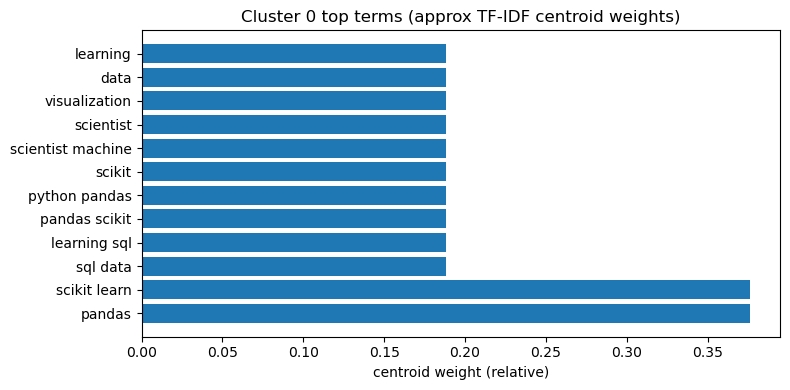

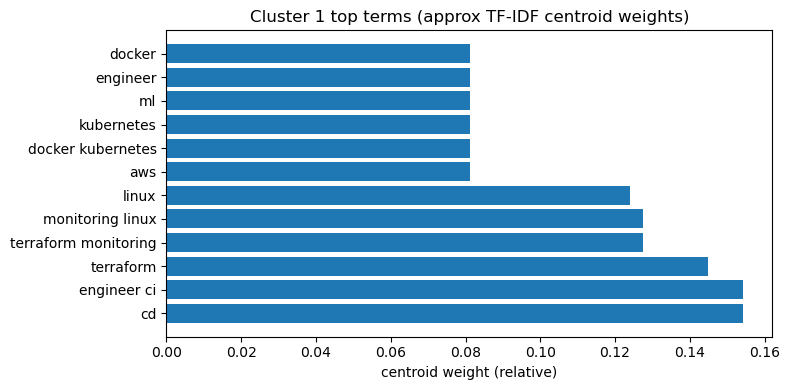

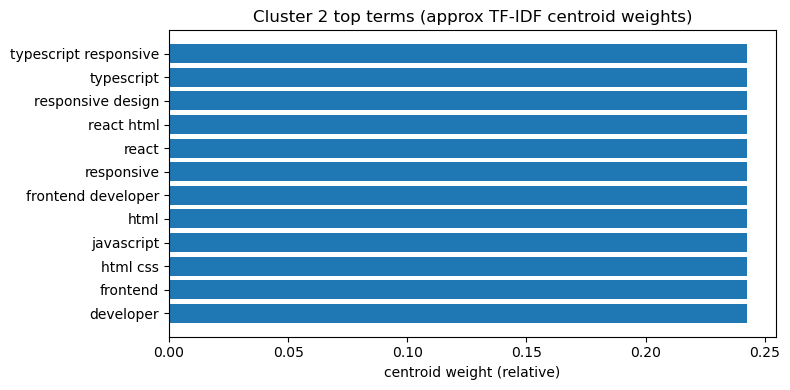

In [11]:
# %%
# Plot top TF-IDF weights for each cluster (visualize the centroid weights)
def plot_cluster_terms(analyzer: SkillGapAnalyzer, cluster_id: int, top_n=12):
    center = analyzer.cluster_centers[cluster_id]
    top_idx = np.argsort(center)[::-1][:top_n]
    terms = [analyzer.feature_names[i] for i in top_idx]
    weights = center[top_idx]
    plt.figure(figsize=(8,4))
    plt.barh(range(len(terms))[::-1], weights[::-1])
    plt.yticks(range(len(terms)), terms[::-1])
    plt.title(f"Cluster {cluster_id} top terms (approx TF-IDF centroid weights)")
    plt.xlabel("centroid weight (relative)")
    plt.tight_layout()
    plt.show()

for c in range(N_CLUSTERS):
    plot_cluster_terms(analyzer, c, top_n=12)

In [12]:
# %%
out_path = "interns_skill_gap_report.csv"
interns_df.to_csv(out_path, index=False)
print(f"Saved results to {out_path}")

Saved results to interns_skill_gap_report.csv
